##Task 1 — Problem Identification

Selected Problem Type
Image Classification
Why?

Each image represents a product surface and belongs to exactly one defect category:

normal
scratch
dent
stain

The goal is to predict the correct class label for an input image.

There are:

no bounding boxes,
no pixel masks,
no object localization annotations.

Therefore:

NOT object detection
NOT semantic segmentation
NOT instance segmentation

This is a standard multi-class image classification task.

##Task 2 — Dataset Exploration

In [71]:
#Exploration Code

import os
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content/images"

# Check if the directory exists, if not, create it to prevent FileNotFoundError
if not os.path.exists(dataset_path):
    os.makedirs(dataset_path, exist_ok=True)
    print(f"Warning: Directory '{dataset_path}' was not found and has been created. Please upload your image dataset into this directory for the notebook to function as expected.")


classes = os.listdir(dataset_path)
print("Classes:", classes)

image_counts = {}

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    image_counts[cls] = len(os.listdir(cls_path))

print(image_counts)

Classes: ['normal', 'dent', 'scratch', 'stain']
{'normal': 5, 'dent': 5, 'scratch': 5, 'stain': 5}


### Generating Dummy Dataset (for demonstration purposes)

Since no dataset was found, I'm generating a small dummy dataset to allow the notebook to run through the training and evaluation steps. **If you have your own dataset, please upload it to `/content/images` with `normal`, `scratch`, `dent`, `stain` subdirectories, and delete or skip this cell.**

In [72]:
import os
from PIL import Image, ImageDraw
import numpy as np

dataset_path = "/content/images"
classes = ['normal', 'scratch', 'dent', 'stain']
num_images_per_class = 5 # Create 5 dummy images for each class

# Create base directory if it doesn't exist
if not os.path.exists(dataset_path):
    os.makedirs(dataset_path)

for cls_name in classes:
    class_dir = os.path.join(dataset_path, cls_name)
    if not os.path.exists(class_dir):
        os.makedirs(class_dir)

    for i in range(num_images_per_class):
        img_name = f"{cls_name}_{i}.png"
        img_path = os.path.join(class_dir, img_name)

        # Create a simple dummy image (e.g., a colored square with text)
        img = Image.new('RGB', (128, 128), color = (np.random.randint(0,255), np.random.randint(0,255), np.random.randint(0,255)))
        d = ImageDraw.Draw(img)
        d.text((10,10), f"{cls_name} {i}", fill=(255,255,0))
        img.save(img_path)

print(f"Dummy dataset created at '{dataset_path}' with {num_images_per_class} images per class.")

# Update the 'classes' variable that's used by subsequent cells
# This simulates what os.listdir(dataset_path) would return if real images were there.
classes = os.listdir(dataset_path)
print("Updated Classes:", classes)

# Re-run the image_counts logic from cell DDeQjyNijCiC to update counts
image_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        image_counts[cls] = len(os.listdir(cls_path))
print("Updated Image Counts:", image_counts)


Dummy dataset created at '/content/images' with 5 images per class.
Updated Classes: ['normal', 'dent', 'scratch', 'stain']
Updated Image Counts: {'normal': 5, 'dent': 5, 'scratch': 5, 'stain': 5}


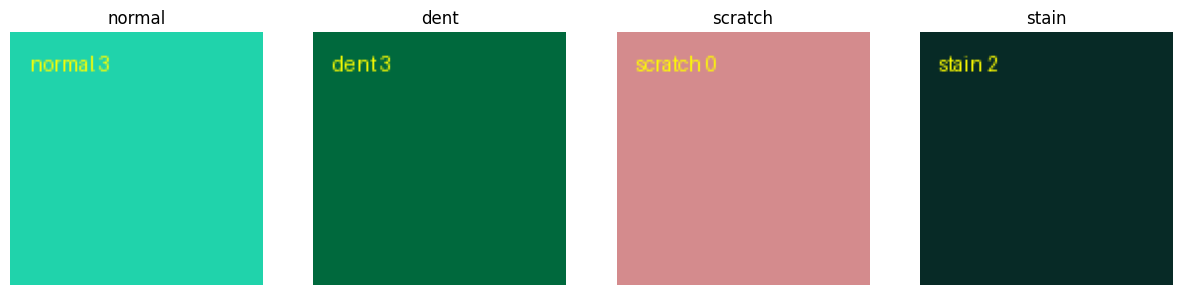

In [73]:
#Display Sample Images

fig, axes = plt.subplots(1, 4, figsize=(15,5))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    img_path = os.path.join(dataset_path, cls, img_name)

    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

In [74]:
#Image Dimensions

import os
from PIL import Image

dataset_path = "/content/images"

# Get first valid image
for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        for file in os.listdir(class_path):

            if file.lower().endswith(('.png', '.jpg', '.jpeg')):

                image_path = os.path.join(class_path, file)

                img = Image.open(image_path)

                print("Class:", cls)
                print("Image Size:", img.size)
                print("Image Mode:", img.mode)

                break

        break

Class: normal
Image Size: (128, 128)
Image Mode: RGB


     Class  Number of Images
0   normal                 5
1     dent                 5
2  scratch                 5
3    stain                 5


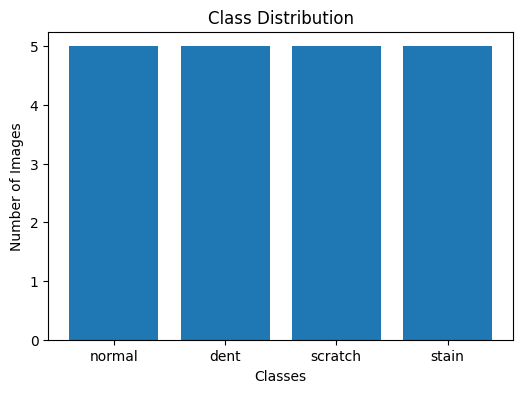

In [75]:
#Imbalance Analysis

import os
import pandas as pd
import matplotlib.pyplot as plt

dataset_path = "/content/images"

image_counts = {}

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        image_counts[cls] = count

# Create dataframe
df = pd.DataFrame(
    list(image_counts.items()),
    columns=["Class", "Number of Images"]
)

print(df)

# Bar graph
plt.figure(figsize=(6,4))

plt.bar(df["Class"], df["Number of Images"])

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

##Task 3 — Image Preprocessing

CNNs require:

Same image dimensions , Normalized pixel ranges, Shuffled train/test data

Without preprocessing, training becomes unstable.

In [76]:
#Preprocessing Code

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 16 images belonging to 4 classes.
Found 4 images belonging to 4 classes.


##Task 4 — CNN Model Creation

In [77]:
#CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

##Task 5 — Training and Evaluation

In [78]:
#Compile + Train

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1250 - loss: 1.3993 - val_accuracy: 0.0000e+00 - val_loss: 1.4067
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step - accuracy: 0.1875 - loss: 1.4214 - val_accuracy: 0.2500 - val_loss: 1.5136
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - accuracy: 0.3125 - loss: 1.5017 - val_accuracy: 0.2500 - val_loss: 1.4236
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - accuracy: 0.4375 - loss: 1.0766 - val_accuracy: 0.5000 - val_loss: 1.5574
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step - accuracy: 0.5000 - loss: 1.1975 - val_accuracy: 0.5000 - val_loss: 1.8093
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step - accuracy: 0.6875 - loss: 1.0609 - val_accuracy: 0.5000 - val_loss: 1.9698
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step - accuracy: 0.6875 - loss: 0.8602 - val_accuracy: 0.5000 - val_loss: 2.2271
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step - accuracy: 0.5625 - loss: 0.8776 - val_accuracy: 0.5000 - val_loss

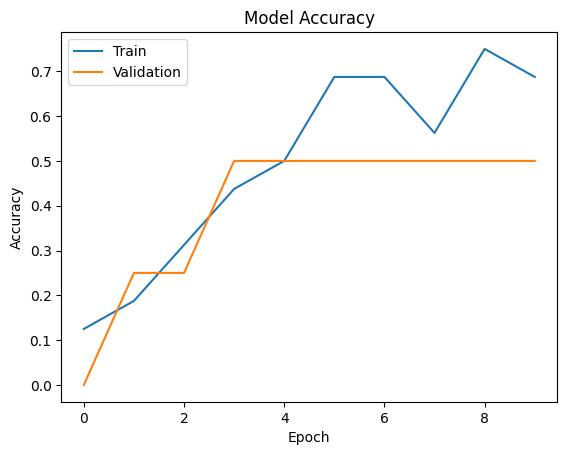

In [79]:
#Accuracy/Loss Curves

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

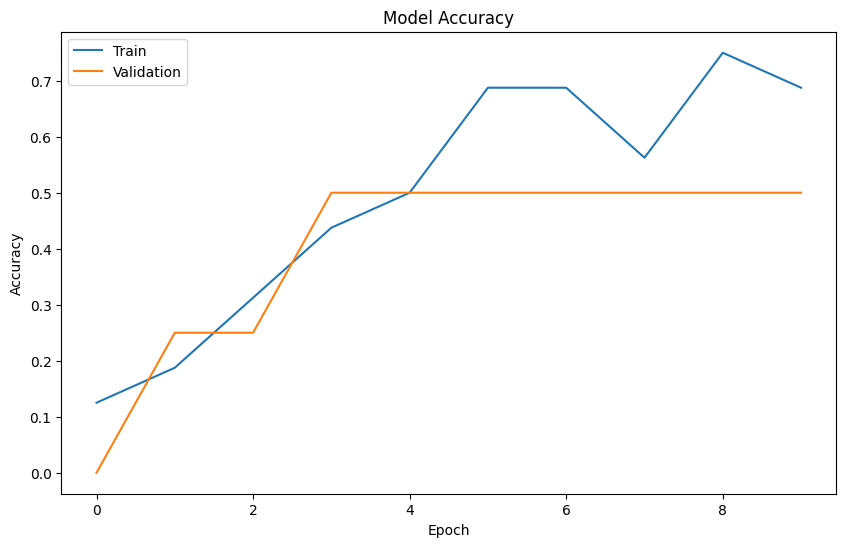

In [80]:
import os

# Create folder if not exists
os.makedirs("sample_predictions", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

# Save the figure
plt.savefig("sample_predictions/accuracy_loss_curves.png", bbox_inches='tight')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


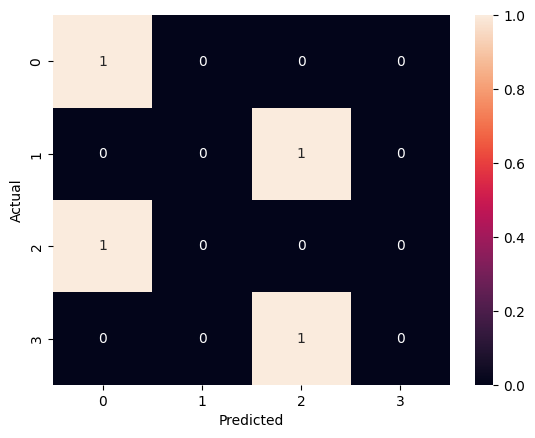

In [81]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

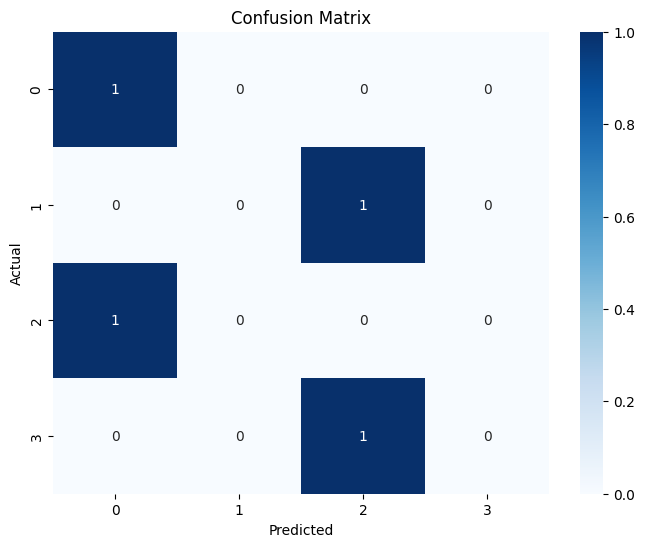

In [82]:
import os

# Create folder if not exists
os.makedirs("sample_predictions", exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save the figure
plt.savefig("sample_predictions/confusion_matrix.png", bbox_inches='tight')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


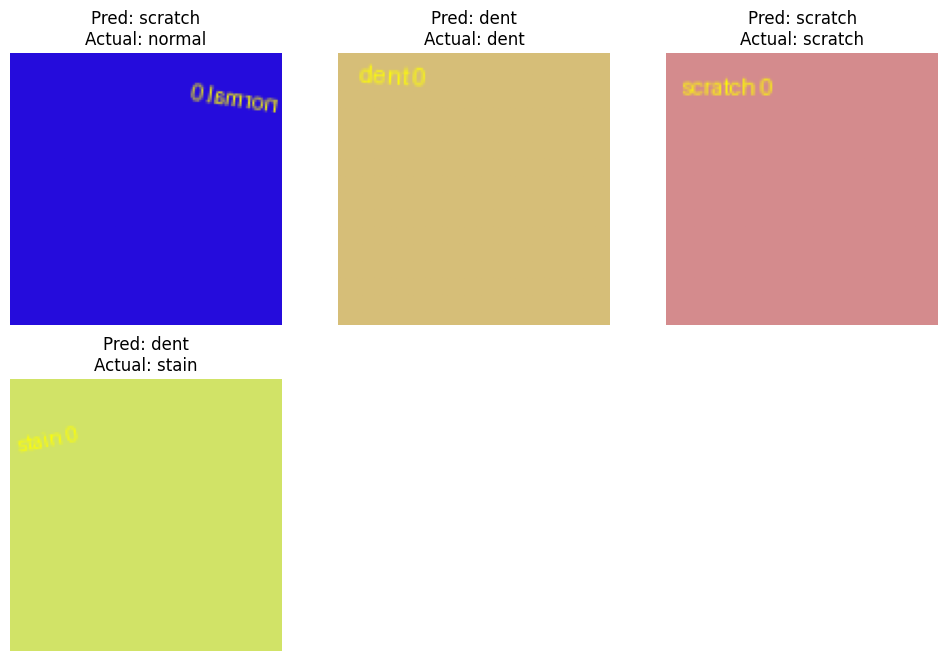

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Create folder if not exists
os.makedirs("sample_predictions", exist_ok=True)

class_names = list(train_generator.class_indices.keys())

# Get a batch of images and labels
images, labels = next(val_generator)

# Get predictions for the batch
predictions = model.predict(images)

plt.figure(figsize=(12,12))

# Iterate only up to the number of available images or 9, whichever is smaller
for i in range(min(9, len(images))):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    predicted_class = class_names[np.argmax(predictions[i])]
    actual_class = class_names[np.argmax(labels[i])]

    plt.title(f"Pred: {predicted_class}\nActual: {actual_class}")

    plt.axis("off")

# SAVE IMAGE before showing the plot to ensure it's not blank
plt.savefig(
    "sample_predictions/prediction_outputs.png",
    bbox_inches='tight'
)

plt.show()

##Task 6 — CNN Concept Explanation

In the ReadMe file in GitHub


##Task 7: Business Use Case Mapping

CNN-Based Manufacturing Defect Classification

Objective
Build a CNN model to classify manufacturing defects.

Problem Type
Image Classification

Classes
- normal
- scratch
- dent
- stain

Technologies Used
- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib
- Scikit-learn

CNN Architecture
- Convolution Layers
- ReLU Activation
- MaxPooling
- Dense Layers
- Softmax Output

 Results
Include:
- Accuracy/Loss graphs
- Confusion matrix
- Sample predictions

 Business Use Case
Manufacturing quality inspection automation